## Loading Data

Goals changed: Metric measurement has changed. 
Delay   = actual_arrival − scheduled_arrival 

What I am now trying to predict:
Headway = this_train_departure − previous_train_departure

Consistent spacing is arguably better than strict adherence to schedule. Now predicting which branch will have the worst headway irregularity.

In [75]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


BRANCHES = ["Green-B", "Green-C", "Green-D", "Green-E"]

BRANCH_COLORS = {
    "Green-B": "#2196F3",
    "Green-C": "#FF9800",
    "Green-D": "#9C27B0",
    "Green-E": "#F44336"
}
DAY_ORDER     = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
SEASON_ORDER  = ["Winter","Spring","Summer","Fall"]
MONTH_ORDER   = ["January","February","March","April","May","June",
                 "July","August","September","October","November","December"]


#Manual mapping of MBTA stop_id to branch for fare tap data, 
#since the API doesn't directly provide branch info at the stop level
STOP_TO_BRANCH = {
    "B Branch": [
        "Blandford Street",
        "Boston University East",
        "Boston University Central",
        "Amory Street",
        "Babcock Street",
        "Packard's Corner",
        "Harvard Avenue",
        "Griggs Street",
        "Allston Street",
        "Warren Street",
        "Washington Street",
        "Sutherland Road",
        "Chiswick Road",
        "Chestnut Hill Avenue",
        "South Street",
        "Boston College",
    ],
    "C Branch": [
        "Saint Mary's Street",
        "Hawes Street",
        "Kent Street",
        "Saint Paul Street",
        "Coolidge Corner",
        "Summit Avenue",
        "Brandon Hall",
        "Fairbanks Street",
        "Washington Square",
        "Tappan Street",
        "Dean Road",
        "Englewood Avenue",
        "Cleveland Circle",
    ],
    "D Branch": [
        "Fenway",
        "Longwood",
        "Brookline Village",
        "Brookline Hills",
        "Beaconsfield",
        "Reservoir",
        "Chestnut Hill",
        "Newton Centre",
        "Newton Highlands",
        "Eliot",
        "Waban",
        "Woodland",
        "Riverside",
    ],
    "E Branch": [
        "Prudential",
        "Symphony",
        "Northeastern University",
        "Museum of Fine Arts",
        "Longwood Medical Area",
        "Brigham Circle",
        "Fenwood Road",
        "Mission Park",
        "Riverway",
        "Back of the Hill",
        "Heath Street",
    ],
}

BRANCH_STOPS = {
    name
    for names in STOP_TO_BRANCH.values()
    for name in names
}

KEEP_COLS = [
    "service_date",
    "branch_route_id",
    "stop_name",
    "parent_station",
    "direction_id",
    "stop_departure_datetime",
    "headway_branch_seconds",
    "headway_trunk_seconds"
]

#Data is updated monthly, so we need to load all 2024-2026 files to get the full date range for modeling. It is current as of April 2026 (excluding April itself), so we will load all files up to that point.
FILES = [ 
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-01_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-02_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-03_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-04_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-05_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-06_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-07_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-08_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-09_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-10_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-11_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-12_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-01_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-02_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-03_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-04_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-05_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-06_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-07_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-08_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-09_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-10_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-11_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2025/2025-12_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2026/2026-01_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2026/2026-02_Headway.csv",
    "/Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2026/2026-03_Headway.csv",
]

chunks = []
for file in FILES:
    print(f"Loading {file}...")
    for chunk in pd.read_csv(file,
                             parse_dates=["service_date",
                                          "stop_departure_datetime"],
                             chunksize=100_000):
        filtered = chunk[
            chunk["branch_route_id"].isin(BRANCHES) &
            chunk["stop_name"].isin(BRANCH_STOPS)
        ][KEEP_COLS]
        chunks.append(filtered)

df = pd.concat(chunks, ignore_index=True)
df = df.sort_values("service_date").reset_index(drop=True)

print(f"Total rows:  {len(df):,}")
print(f"Date range:  {df['service_date'].min()} → {df['service_date'].max()}")
print(f"Memory:      {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-01_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-02_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-03_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-04_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-05_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-06_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-07_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-08_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/2024-09_Headway.csv...
Loading /Users/josephsteriti/Downloads/CS 506/Final Project/data/Headways_2024/202

In [76]:
# Compare average headway per branch between years — 
# if they're wildly different, there may be a methodology shift
df["year"] = df["service_date"].dt.year
print(df[df["branch_route_id"].isin(["Green-B","Green-C","Green-D","Green-E"])]
      .groupby(["year", "branch_route_id"])["headway_branch_seconds"]
      .median()
      .unstack("branch_route_id")
      .round(1))

branch_route_id  Green-B  Green-C  Green-D  Green-E
year                                               
2024               546.0    540.0    562.0    495.0
2025               548.0    533.0    530.0    502.0
2026               579.0    552.0    569.0    543.0


In [77]:
KEEP_COLS = [
    "service_date",           # date-level features (day of week, month, season)
    "branch_route_id",        # your branch label (B/C/D/E)
    "direction_id",           # inbound vs outbound — headway often differs
    "parent_station",         # stop-level aggregation
    "stop_name",              # for filtering to your branch stops
    "stop_departure_datetime",# gives you hour of day for rush hour features
    "headway_branch_seconds", # your target metric
]

df = df[KEEP_COLS]

#Creating a single CSV for easier loading into the notebook later.
df.to_csv("green_line_headways.csv", index=False)

## Feature Engineering

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

df = pd.read_csv("green_line_headways.csv",
                 parse_dates=["service_date", "stop_departure_datetime"])

# ── Feature engineering
df["day_of_week"] = df["service_date"].dt.dayofweek
df["day_name"]     = df["service_date"].dt.day_name()
df["month"]       = df["service_date"].dt.month
df["month_name"]   = df["service_date"].dt.month_name()
df["hour"]        = df["stop_departure_datetime"].dt.hour
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)
df["is_rush_hour"] = (df["hour"].between(7, 9) | df["hour"].between(16, 19)).astype(int)

#Season mapping can be adjusted based on solstices, but this is a common approach.
#If month is majority in one season, assign that season. This is a simplification but works for basic modeling.
#Also pretty accurate for Boston, where the weather patterns are fairly consistent with these month-based seasons.
#Literally snowed yesterday in (first few days of April), so I think this is a reasonable mapping for our purposes.
df["season"]       = df["month"].map({
    12: "Fall", 1: "Winter", 2: "Winter",
     3: "Winter", 4: "Spring", 5: "Spring",
     6: "Spring", 7: "Summer", 8: "Summer",
     9: "Summer",  10: "Fall",  11: "Fall"
})

df["headway_min"]  = df["headway_branch_seconds"] / 60
#TODO: Add weather, alerts, and special events. I believe weather will strongly improve the model, especially for predicting outliers
#weather_cols = ["precipitation_sum", "snowfall_sum", "windspeed_max", "temp_mean"]

# alerts = pd.read_csv("alerts.csv", parse_dates=["alert_date"])

# is_special_event = pd.read_csv("special_events.csv", parse_dates=["event_date"])

#FEATURES = [
#     "is_special_event", "has_alert",
#     "precipitation_sum", "snowfall_sum", "windspeed_max", "temp_mean",
# 
# ]

# ── Aggregate to one row per branch per day ────────────────────────────────────
# This is your actual modeling dataframe
daily = (df.groupby(["service_date", "branch_route_id"])
           .agg(
               avg_headway   = ("headway_branch_seconds", "mean"),
               max_headway   = ("headway_branch_seconds", "max"),
               std_headway   = ("headway_branch_seconds", "std"),
               #median_headway = ("headway_branch_seconds", "median"), - heavily correlated with avg_headway, so dropping for now to reduce multicollinearity
               day_of_week   = ("day_of_week", "first"),
               day_name       = ("day_name",     "first"),
               month         = ("month", "first"),
               month_name     = ("month_name",   "first"),
               hour           = ("hour",         "first"),
               is_weekend    = ("is_weekend", "first"),
               is_rush_hour  = ("is_rush_hour", "max"),
               season         = ("season",       "first"),
           )
           .reset_index()
           .sort_values("service_date")
           .reset_index(drop=True)
)

In [ ]:
#Adding lag features to capture recent trends for each branch. 
#These can help the model understand if a branch is currently performing better or worse than its recent average, which is often a strong predictor of near-term performance.
daily = daily.sort_values(["branch_route_id", "service_date"]).reset_index(drop=True)

daily["headway_lag_1d"] = (daily.groupby("branch_route_id")["avg_headway"]
                                 .shift(1))

daily["headway_lag_7d"] = (daily.groupby("branch_route_id")["avg_headway"]
                                 .shift(7))

daily["headway_rolling_7d"] = (daily.groupby("branch_route_id")["avg_headway"]
                                     .transform(lambda x: x.shift(1)
                                                            .rolling(7)
                                                            .mean()))

daily["headway_rolling_30d"] = (daily.groupby("branch_route_id")["avg_headway"]
                                      .transform(lambda x: x.shift(1)
                                                             .rolling(30)
                                                             .mean()))

# How much worse is this branch vs its own recent average?
daily["headway_vs_rolling"] = (daily["avg_headway"] - 
                                daily["headway_rolling_7d"])

daily = daily.sort_values("service_date").reset_index(drop=True)


print("NaNs after lag features:")
print(daily[["headway_lag_1d", "headway_lag_7d",
             "headway_rolling_7d", "headway_rolling_30d",
             "headway_vs_rolling"]].isna().sum())

print(f"\nRows before dropping NaN lags: {len(daily)}")
daily = daily.dropna(subset=["headway_lag_1d", "headway_lag_7d",
                              "headway_rolling_7d", "headway_rolling_30d"])
print(f"Rows after dropping NaN lags:  {len(daily)}")
# After computing lag features and dropping NaNs
daily = daily.dropna(subset=["headway_lag_1d", "headway_lag_7d",
                              "headway_rolling_7d", "headway_rolling_30d"])

# Add branch dummies before the training loop
branch_dummies = pd.get_dummies(daily["branch_route_id"], prefix="branch")
daily = pd.concat([daily, branch_dummies], axis=1)

# Rename columns to avoid the dash causing issues
# Don't think this is needed anymore but still keeping
daily = daily.rename(columns={
    "branch_Green-B": "branch_Green_B",
    "branch_Green-C": "branch_Green_C",
    "branch_Green-D": "branch_Green_D",
    "branch_Green-E": "branch_Green_E",
})

print("Columns added:", [c for c in daily.columns if "branch_Green" in c])

# Label the worst branch each day
daily["worst_branch"] = (
    daily.groupby("service_date")["avg_headway"]
         .transform(lambda x: x == x.max())
         .astype(int)
)

sns.set_theme(style="whitegrid", font_scale=1.1)

NaNs after lag features:
headway_lag_1d          24
headway_lag_7d          48
headway_rolling_7d      80
headway_rolling_30d    287
headway_vs_rolling      85
dtype: int64

Rows before dropping NaN lags: 3208
Rows after dropping NaN lags:  2921
Columns added: ['branch_Green_B', 'branch_Green_C', 'branch_Green_D', 'branch_Green_E']


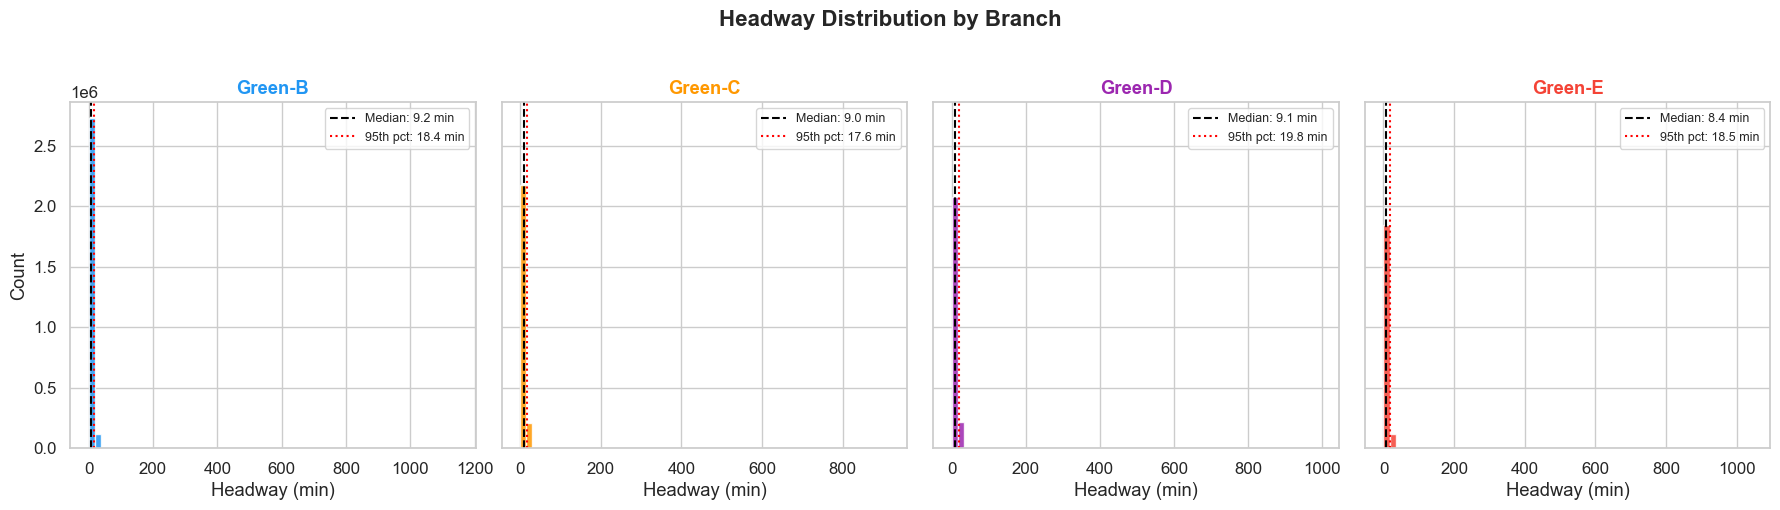

In [ ]:
#Headway distribution per branch
#TODO: Needs to be fixed
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle("Headway Distribution by Branch", fontsize=16, fontweight="bold", y=1.02)

for ax, branch in zip(axes, BRANCHES):
    data = df[df["branch_route_id"] == branch]["headway_min"]
    ax.hist(data, bins=60, color=BRANCH_COLORS[branch], alpha=0.85, edgecolor="white")
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {data.median():.1f} min")
    ax.axvline(data.quantile(0.95), color="red", linestyle=":", linewidth=1.5,
               label=f"95th pct: {data.quantile(0.95):.1f} min")
    ax.set_title(branch, fontweight="bold", color=BRANCH_COLORS[branch])
    ax.set_xlabel("Headway (min)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
#axes[0].set_xlim(0, 30)

plt.tight_layout()
plt.savefig("01_headway_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

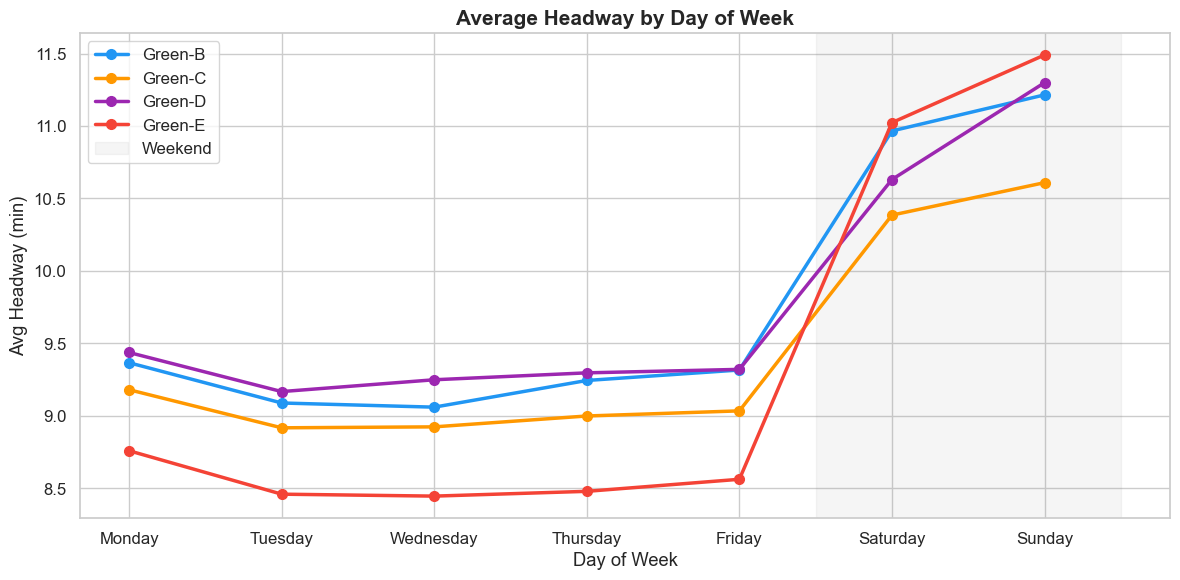

In [81]:
#Average headway by day of week per branch
fig, ax = plt.subplots(figsize=(12, 6))

day_branch = (df.groupby(["day_name", "branch_route_id"])["headway_min"]
                .mean()
                .reset_index())
day_branch["day_name"] = pd.Categorical(day_branch["day_name"],
                                        categories=DAY_ORDER, ordered=True)
day_branch = day_branch.sort_values("day_name").reset_index(drop=True)

for branch in BRANCHES:
    subset = day_branch[day_branch["branch_route_id"] == branch]
    ax.plot(subset["day_name"], subset["headway_min"],
            marker="o", linewidth=2.5, markersize=7,
            color=BRANCH_COLORS[branch], label=branch)

ax.axvspan(4.5, 6.5, alpha=0.08, color="gray", label="Weekend")
ax.set_title("Average Headway by Day of Week", fontsize=15, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Headway (min)")
ax.legend()
plt.tight_layout()
plt.savefig("02_headway_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

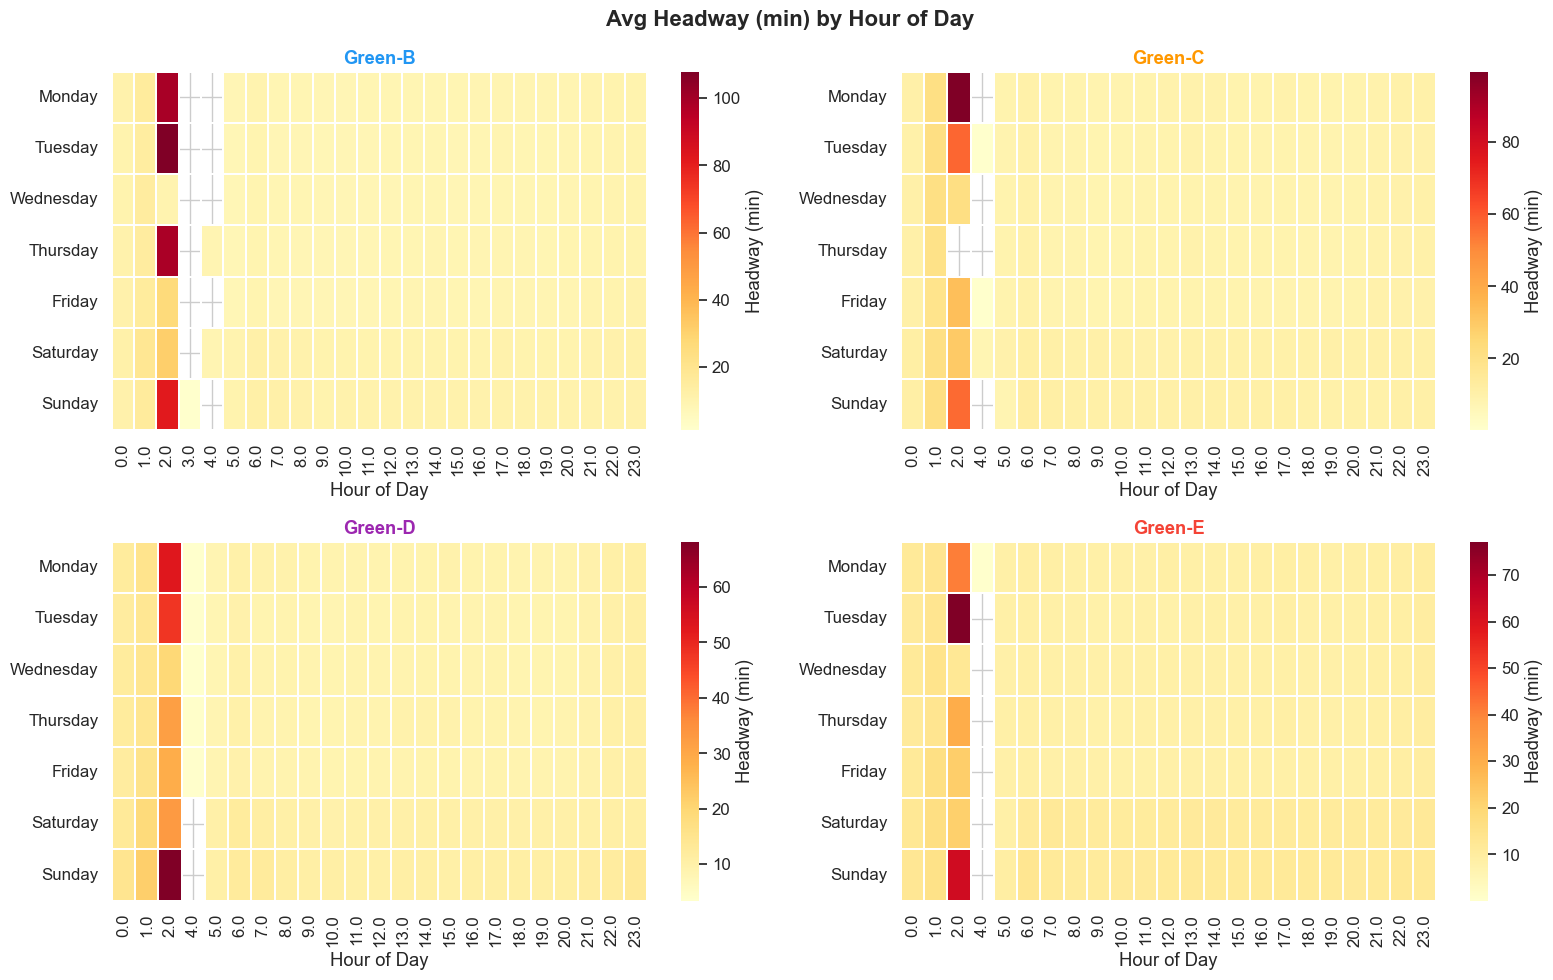

In [ ]:
import numpy as np

#TODO: Fix this to show actual hour of day heat, not actually working correctly
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Avg Headway (min) by Hour of Day", fontsize=16, fontweight="bold")

for ax, branch in zip(axes.flat, BRANCHES):
    pivot = (df[df["branch_route_id"] == branch]
               .groupby(["day_name", "hour"])["headway_min"]
               .mean()
               .unstack("hour"))
    pivot = pivot.reindex(DAY_ORDER)

    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=False,
                linewidths=0.3, cbar_kws={"label": "Headway (min)"})
    ax.set_title(branch, fontweight="bold", color=BRANCH_COLORS[branch])
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("03_heatmap_branch_hour.png", dpi=150, bbox_inches="tight")
plt.show()

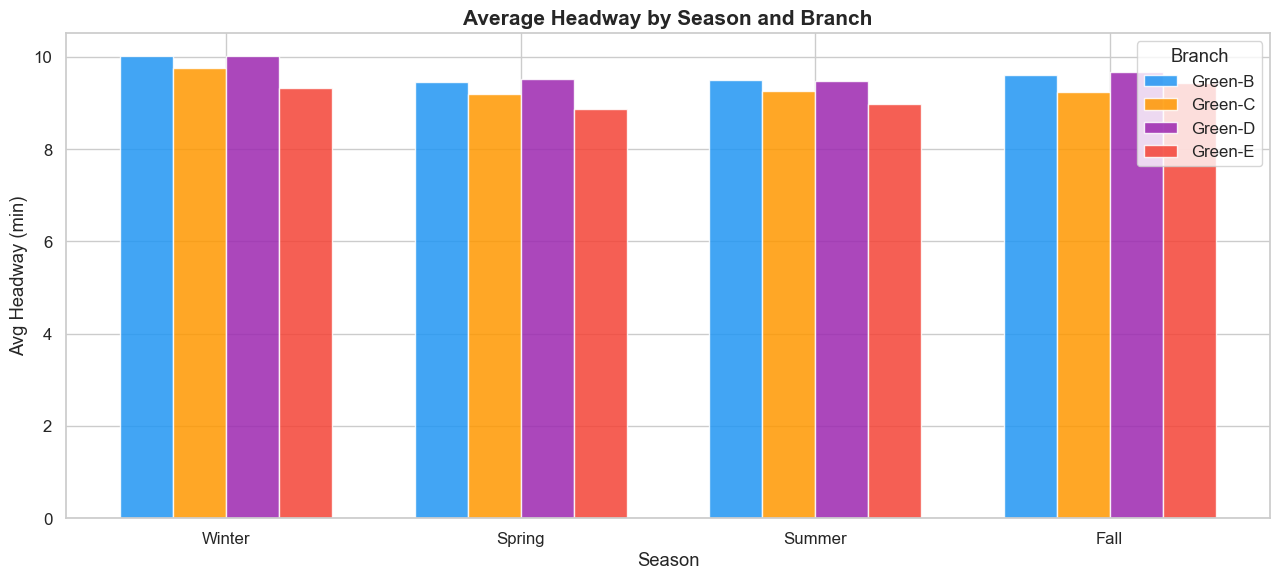

In [83]:
#Headway by season
fig, ax = plt.subplots(figsize=(13, 6))

season_data = (df[df["branch_route_id"].isin(BRANCHES)]
                 .groupby(["season", "branch_route_id"])["headway_min"]
                 .mean()
                 .reset_index())
season_data["season"] = pd.Categorical(season_data["season"],
                                        categories=SEASON_ORDER, ordered=True)
season_data = season_data.sort_values("season").reset_index(drop=True)

x    = np.arange(len(SEASON_ORDER))
w    = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for branch, offset in zip(BRANCHES, offsets):
    vals = [season_data[(season_data["branch_route_id"] == branch) &
                        (season_data["season"] == s)]["headway_min"].values
            for s in SEASON_ORDER]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    ax.bar(x + offset * w, vals, width=w,
           color=BRANCH_COLORS[branch], label=branch, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER)
ax.set_title("Average Headway by Season and Branch", fontsize=15, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Headway (min)")
ax.legend(title="Branch")
plt.tight_layout()
plt.savefig("05_headway_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

Season does not seem to affect headway very much

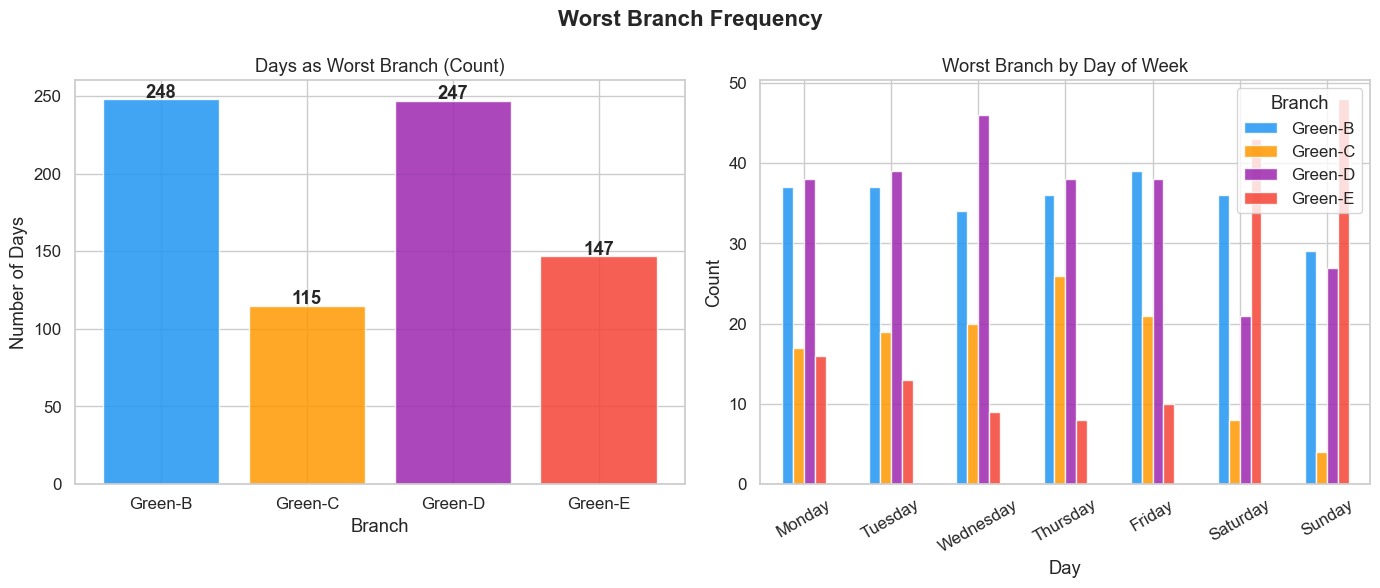

In [84]:
#Which branch is worst most often
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Worst Branch Frequency", fontsize=16, fontweight="bold")

# Left: raw count
worst_counts = (daily[daily["worst_branch"] == 1]
                    .groupby("branch_route_id")
                    .size()
                    .reindex(BRANCHES))

axes[0].bar(BRANCHES, worst_counts,
            color=[BRANCH_COLORS[b] for b in BRANCHES], alpha=0.85)
axes[0].set_title("Days as Worst Branch (Count)")
axes[0].set_xlabel("Branch")
axes[0].set_ylabel("Number of Days")
for i, v in enumerate(worst_counts):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

# Right: by day of week
worst_day = (daily[daily["worst_branch"] == 1]
                 .groupby(["day_name", "branch_route_id"])
                 .size()
                 .unstack("branch_route_id")
                 .reindex(DAY_ORDER)
                 .fillna(0))

worst_day.plot(kind="bar", ax=axes[1],
               color=[BRANCH_COLORS[b] for b in worst_day.columns],
               alpha=0.85, edgecolor="white")
axes[1].set_title("Worst Branch by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Count")
axes[1].legend(title="Branch")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("06_worst_branch_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

Branch E goes directly to Prudential and Newbury (shopping district) which would make sense for the weekends.

plot_data shape:      (9718303, 17)
is_rush_hour unique:  [0 1]
period unique:        <StringArray>
['Non-Rush Hour', 'Rush Hour']
Length: 2, dtype: str
headway_min nulls:    202237
branch counts:
 branch_route_id
Green-B    2899928
Green-C    2436705
Green-D    2363411
Green-E    2018259
Name: count, dtype: int64
rush rows:            (3567737, 17)
non_rush rows:        (6150566, 17)


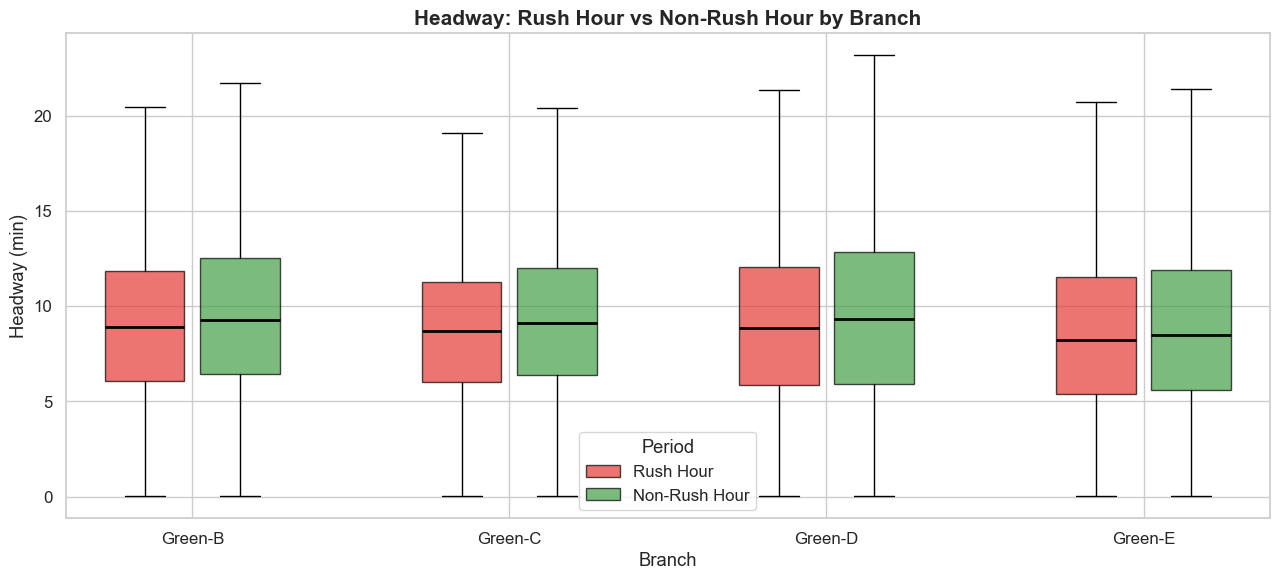

In [85]:
#Rush hour vs non-rush hour headway comparison boxplot
fig, ax = plt.subplots(figsize=(13, 6))

plot_data = df[df["branch_route_id"].isin(BRANCHES)].copy()
plot_data["period"] = plot_data["is_rush_hour"].map(
    {1: "Rush Hour", 0: "Non-Rush Hour"})

print("plot_data shape:     ", plot_data.shape)
print("is_rush_hour unique: ", plot_data["is_rush_hour"].unique())
print("period unique:       ", plot_data["period"].unique())
print("headway_min nulls:   ", plot_data["headway_min"].isna().sum())
print("branch counts:\n",      plot_data["branch_route_id"].value_counts())
print("rush rows:           ", plot_data[plot_data["period"] == "Rush Hour"].shape)
print("non_rush rows:       ", plot_data[plot_data["period"] == "Non-Rush Hour"].shape)

# Split into two separate plots instead of hue
rush     = plot_data[plot_data["period"] == "Rush Hour"]
non_rush = plot_data[plot_data["period"] == "Non-Rush Hour"]

positions_rush     = [0.8, 2.8, 4.8, 6.8]
positions_non_rush = [1.4, 3.4, 5.4, 7.4]

bp1 = ax.boxplot([rush[rush["branch_route_id"] == b]["headway_min"].dropna()
                  for b in BRANCHES],
                 positions=positions_rush, widths=0.5,
                 patch_artist=True, showfliers=False,
                 boxprops=dict(facecolor="#E53935", alpha=0.7),
                 medianprops=dict(color="black", linewidth=2))

bp2 = ax.boxplot([non_rush[non_rush["branch_route_id"] == b]["headway_min"].dropna()
                  for b in BRANCHES],
                 positions=positions_non_rush, widths=0.5,
                 patch_artist=True, showfliers=False,
                 boxprops=dict(facecolor="#43A047", alpha=0.7),
                 medianprops=dict(color="black", linewidth=2))

ax.set_xticks([1.1, 3.1, 5.1, 7.1])
ax.set_xticklabels(BRANCHES)
ax.set_title("Headway: Rush Hour vs Non-Rush Hour by Branch",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Branch")
ax.set_ylabel("Headway (min)")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]],
          ["Rush Hour", "Non-Rush Hour"], title="Period")
plt.tight_layout()
plt.savefig("04_rush_vs_nonrush.png", dpi=150, bbox_inches="tight")
plt.show()

Shows high variability, but the difference between rush hour and non rush hour medians are not significant

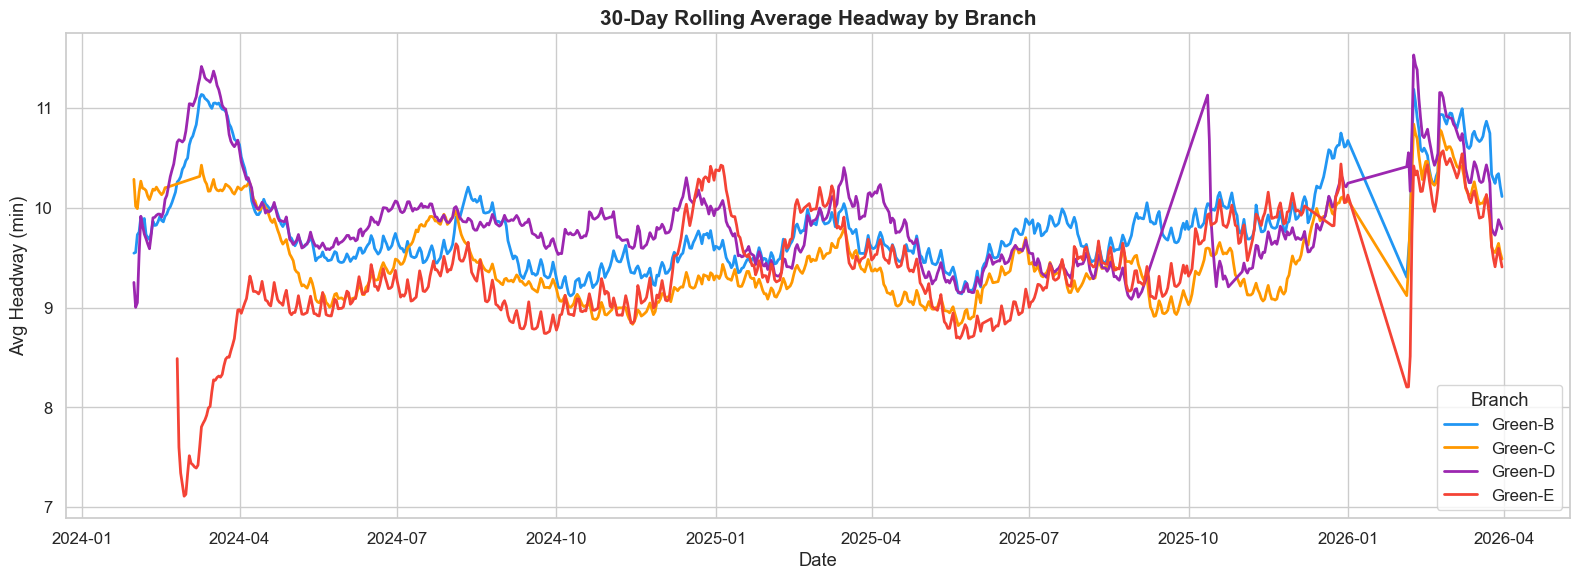

In [86]:
#Rolling 30-day average headway per branch
fig, ax = plt.subplots(figsize=(16, 6))

for branch in BRANCHES:
    subset = (daily[daily["branch_route_id"] == branch]
                   .set_index("service_date")["avg_headway"]
                   .sort_index()
                   .rolling("30D")
                   .mean())
    ax.plot(subset.index, subset / 60,
            color=BRANCH_COLORS[branch], linewidth=2, label=branch)

ax.set_title("30-Day Rolling Average Headway by Branch",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Headway (min)")
ax.legend(title="Branch")
plt.tight_layout()
plt.savefig("07_rolling_headway.png", dpi=150, bbox_inches="tight")
plt.show()

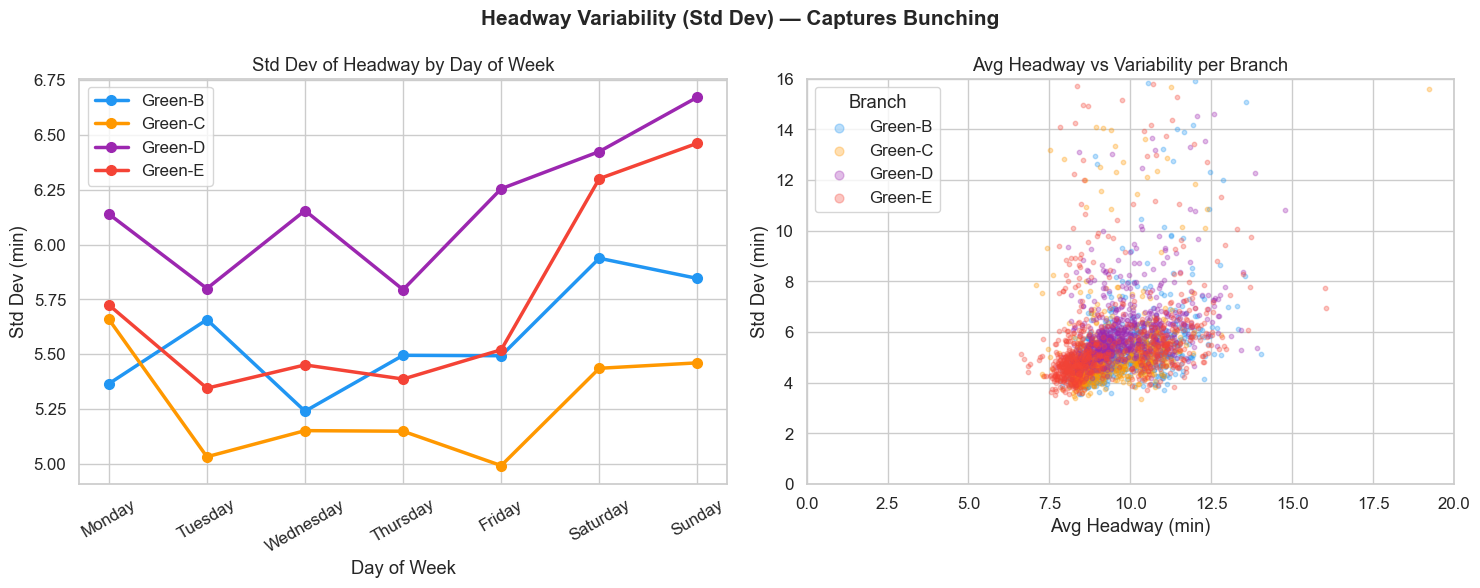

In [87]:
#Headway variability (std) — key model signal
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Headway Variability (Std Dev) — Captures Bunching",
             fontsize=15, fontweight="bold")

# Left: std by branch and day of week
std_day = (daily.groupby(["day_name", "branch_route_id"])["std_headway"]
                .mean()
                .reset_index())
std_day["day_name"] = pd.Categorical(std_day["day_name"],
                                      categories=DAY_ORDER, ordered=True)
std_day = std_day.sort_values("day_name").reset_index(drop=True)

for branch in BRANCHES:
    subset = std_day[std_day["branch_route_id"] == branch]
    axes[0].plot(subset["day_name"], subset["std_headway"] / 60,
                 marker="o", linewidth=2.5, markersize=7,
                 color=BRANCH_COLORS[branch], label=branch)

axes[0].set_title("Std Dev of Headway by Day of Week")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Std Dev (min)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Right: avg headway vs std — branches that are both slow AND inconsistent
for branch in BRANCHES:
    subset = daily[daily["branch_route_id"] == branch]
    axes[1].scatter(subset["avg_headway"] / 60,
                    subset["std_headway"] / 60,
                    color=BRANCH_COLORS[branch], alpha=0.3, s=10, label=branch)

axes[1].set_title("Avg Headway vs Variability per Branch")
axes[1].set_xlabel("Avg Headway (min)")
axes[1].set_ylabel("Std Dev (min)")
axes[1].legend(title="Branch", markerscale=2)
std_cap = daily["std_headway"].quantile(0.95) / 60
avg_cap = daily["avg_headway"].quantile(0.95) / 60
axes[1].set_ylim(0, 16)
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.savefig("08_headway_variability.png", dpi=150, bbox_inches="tight")
plt.show()

Very useful. Consider using a coefficient of variation. It normalizes "badness". Or consider using Excess Wait Time where passenger-focused metric that specifically penalizes large gaps by squaring headway to penalize extreme cases

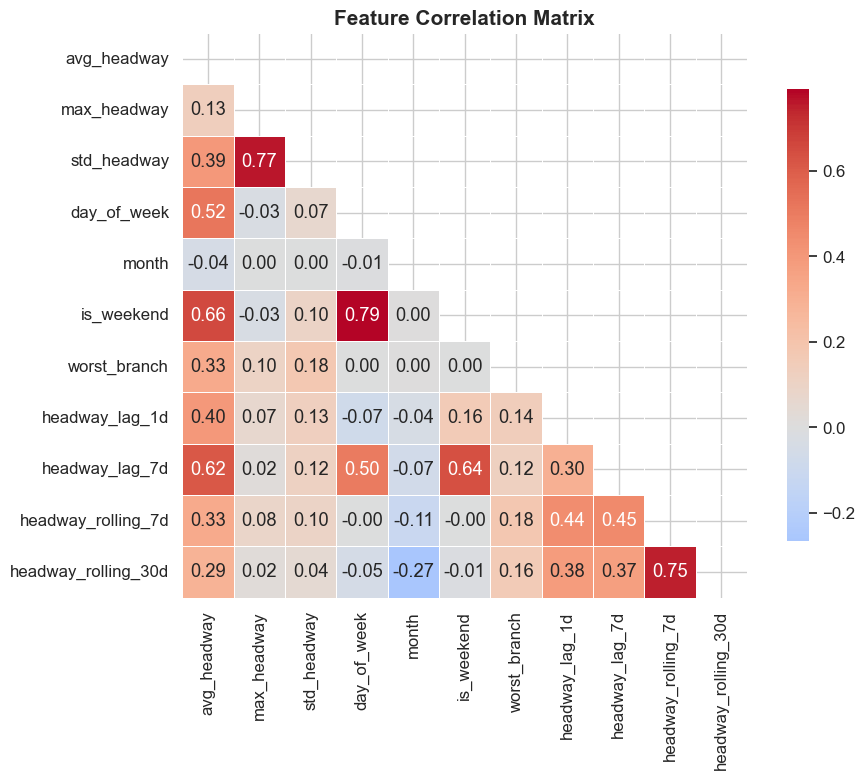

In [105]:
#Correlation matrix of numeric features
fig, ax = plt.subplots(figsize=(10, 8))

corr_features = daily[[
    "avg_headway", "max_headway", "std_headway",
    "day_of_week", "month", "is_weekend", "worst_branch", "headway_lag_1d", "headway_lag_7d",
    "headway_rolling_7d", "headway_rolling_30d",
]].corr()

mask = np.triu(np.ones_like(corr_features, dtype=bool))
sns.heatmap(corr_features, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("09_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

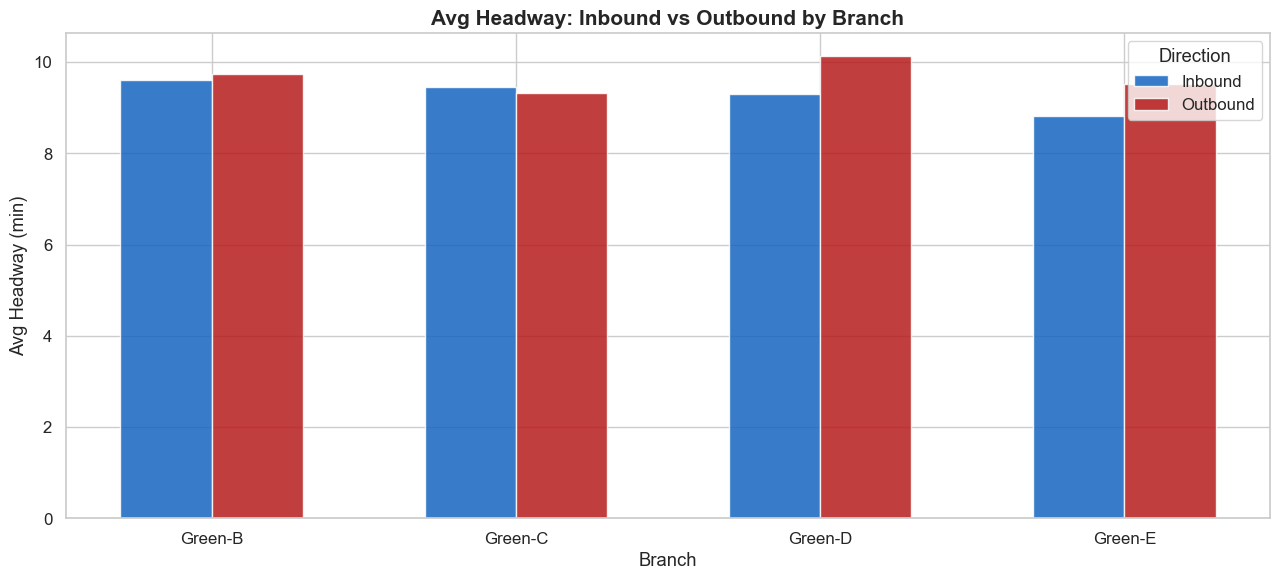

In [89]:
#Inbound vs outbound headway
fig, ax = plt.subplots(figsize=(13, 6))

dir_data = (df[df["branch_route_id"].isin(BRANCHES)]
              .groupby(["branch_route_id", "direction_id"])["headway_min"]
              .mean()
              .reset_index())
dir_data["direction"] = dir_data["direction_id"].map(
    {0: "Outbound", 1: "Inbound"})

x       = np.arange(len(BRANCHES))
w       = 0.3
colors  = {"Inbound": "#1565C0", "Outbound": "#B71C1C"}

for i, (direction, offset) in enumerate(zip(["Inbound", "Outbound"], [-0.5, 0.5])):
    vals = [dir_data[(dir_data["branch_route_id"] == b) &
                     (dir_data["direction"] == direction)]["headway_min"].values
            for b in BRANCHES]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    ax.bar(x + offset * w, vals, width=w,
           color=colors[direction], label=direction, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(BRANCHES)
ax.set_title("Avg Headway: Inbound vs Outbound by Branch",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Branch")
ax.set_ylabel("Avg Headway (min)")
ax.legend(title="Direction")
plt.tight_layout()
plt.savefig("10_inbound_vs_outbound.png", dpi=150, bbox_inches="tight")
plt.show()

In [96]:
from sklearn.model_selection import TimeSeriesSplit

FEATURES = [
    "day_of_week", "hour", "is_weekend", "is_rush_hour", "month",
    "branch_Green_B",
    "branch_Green_C",
    "branch_Green_D",
    "branch_Green_E",
    #"is_special_event", "has_alert",
    #"precipitation_sum", "snowfall_sum", "windspeed_max", "temp_mean",
    #"delay_lag_1d", "delay_rolling_7d", "n_trips"
    
    #These should start differentiating the branches, so they should be more predictive than the raw branch label. 
    #They also capture recent trends, which is important for a time series model.
    "headway_lag_1d",       # yesterday's headway for THIS branch
    "headway_lag_7d",       # same day last week for THIS branch
    "headway_rolling_7d",   # 7-day average for THIS branch
    "headway_rolling_30d",
]

TARGET = "avg_headway"

daily = daily.sort_values("service_date").reset_index(drop=True)

# ── Time-based train / test split (last 20% of dates = test) ──────────────────
# This is time series data, so we must split chronologically to avoid data leakage. 
# We will use the first 80% of dates for training and the last 20% for testing. 
cutoff = daily["service_date"].quantile(0.8)

# ── TimeSeriesSplit for cross validation inside training set only ───────────────
tscv = TimeSeriesSplit(n_splits=5) 

## Creating Model

In [97]:

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

branch_models = {}
branch_results = {}

param = {
    "n_estimators":  [100, 300],
    "max_depth":     [3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
}

print("Branch dummy columns added:")
print(branch_dummies.columns.tolist())
print(daily.shape)

# We will train a separate model for each branch, since they have different patterns and signals.
for branch in BRANCHES:
    print(f"\n{'='*50}")
    print(f"Training model for branch: {branch}")
    print(f"{'='*50}\n")

    branch_df = daily[daily["branch_route_id"] == branch].reset_index(drop=True)
    print(f"  Rows after dropping NaNs: {len(branch_df):,}")

    # Drop rows where target is NaN before splitting
    branch_df = branch_df.dropna(subset=[TARGET] + FEATURES).reset_index(drop=True)

    print(f"  Rows after dropping NaNs: {len(branch_df):,}")


    train_df = branch_df[branch_df["service_date"] <= cutoff]
    test_df  = branch_df[branch_df["service_date"] > cutoff]

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET]
    X_test  = test_df[FEATURES]
    y_test  = test_df[TARGET]

    #This is to fix an issue where XGBoost was throwing an error about input data types. Converting to numpy arrays seems to resolve it.
    X_train = X_train.to_numpy()
    y_train = y_train.to_numpy()
    X_test  = X_test.to_numpy()
    y_test  = y_test.to_numpy()

    grid_search = GridSearchCV(
        estimator=XGBRegressor(),
        param_grid= param,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_mae   = -grid_search.best_score_
    print(f"  Best params:  {best_params}")
    print(f"  Best CV MAE: {best_mae/60:.2f} min")

    # Refit best model on full training set
    best_model = grid_search.best_estimator_
    test_pred = best_model.predict(X_test)

    print(f"\n  Prediction range: {test_pred.min()/60:.1f} – "
      f"{test_pred.max()/60:.1f} min")
    print(f"  Actual range:     {y_test.min()/60:.1f} – "
        f"{y_test.max()/60:.1f} min")
    print(f"  Prediction std:   {test_pred.std()/60:.2f} min")
    print(f"  Actual std:       {y_test.std()/60:.2f} min")

    # print("X_train NaNs:\n", X_train.isna().sum())
    # print("X_test NaNs:\n",  X_test.isna().sum())
    # print("y_train NaNs:",   y_train.isna().sum())
    # print("y_test NaNs:",    y_test.isna().sum())
    # print("test_preds NaNs:", np.isnan(test_pred).sum())

    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    naive_preds = np.full(len(y_test), y_train.mean())
    naive_mae   = mean_absolute_error(y_test, naive_preds)

    print(f"\n  Test MAE:       {mae/60:.2f} min")
    print(f"  Test RMSE:      {rmse/60:.2f} min")
    print(f"  Naive MAE:      {naive_mae/60:.2f} min")
    print(f"  Improvement:    {(naive_mae - mae)/60:+.2f} min")

    branch_models[branch]  = best_model
    branch_results[branch] = {
        "model":       best_model,
        "test_df":     test_df,
        "X_test":      X_test,
        "y_test":      y_test,
        "test_preds":  test_pred,
        "mae":         mae,
        "rmse":        rmse,
        "naive_mae":   naive_mae,
    }

Branch dummy columns added:
['branch_Green-B', 'branch_Green-C', 'branch_Green-D', 'branch_Green-E']
(2921, 24)

Training model for branch: Green-B

  Rows after dropping NaNs: 758
  Rows after dropping NaNs: 757
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
  Best CV MAE: 0.57 min

  Prediction range: 8.8 – 12.4 min
  Actual range:     8.1 – 21.8 min
  Prediction std:   0.90 min
  Actual std:       1.64 min

  Test MAE:       0.69 min
  Test RMSE:      1.32 min
  Naive MAE:      1.18 min
  Improvement:    +0.49 min

Training model for branch: Green-C

  Rows after dropping NaNs: 740
  Rows after dropping NaNs: 739
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV MAE: 0.48 min

  Prediction range: 8.0 – 11.4 min
  Actual range:     7.3 – 19.2 min
  Prediction std:   0.79 min
  Actual std:       1.3

In [98]:
# ── Predict worst branch per day on test set ───────────────────────────────────

# Collect predictions for all branches on test dates
test_dates = daily[daily["service_date"] > cutoff]["service_date"].unique()

pred_rows = []
for branch in BRANCHES:
    res = branch_results[branch]
    test_df = res["test_df"].copy()

    test_df["predicted_headway"] = res["test_preds"][:len(test_df)]
    pred_rows.append(test_df[["service_date", "branch_route_id",
                               "avg_headway", "predicted_headway"]])

pred_df = pd.concat(pred_rows).sort_values(["service_date", "branch_route_id"]).drop_duplicates(subset=["service_date", "branch_route_id"], keep="first").reset_index(drop=True)

# Predicted worst branch = highest predicted headway per day
predicted_worst = (pred_df.loc[pred_df.groupby("service_date")["predicted_headway"]
                                      .idxmax()]
                          [["service_date", "branch_route_id"]]
                          .rename(columns={"branch_route_id": "predicted_worst"})
                          .reset_index(drop=True))

# Actual worst branch = highest actual headway per day
actual_worst = (pred_df.loc[pred_df.groupby("service_date")["avg_headway"]
                                   .idxmax()]
                       [["service_date", "branch_route_id"]]
                       .rename(columns={"branch_route_id": "actual_worst"})
                       .reset_index(drop=True))

comparison = predicted_worst.merge(actual_worst, on="service_date")
accuracy   = (comparison["predicted_worst"] == comparison["actual_worst"]).mean()

print(f"\nWorst-branch prediction accuracy: {accuracy*100:.1f}%")
print(comparison.head(10).to_string(index=False))


Worst-branch prediction accuracy: 44.5%
service_date predicted_worst actual_worst
  2025-09-24         Green-C      Green-B
  2025-09-25         Green-C      Green-C
  2025-09-26         Green-B      Green-C
  2025-09-27         Green-E      Green-B
  2025-09-28         Green-E      Green-E
  2025-09-29         Green-B      Green-B
  2025-09-30         Green-B      Green-E
  2025-10-01         Green-B      Green-C
  2025-10-02         Green-B      Green-B
  2025-10-03         Green-B      Green-E


In [100]:
# What does always guessing the most common branch get you?
most_common = comparison["actual_worst"].value_counts().idxmax()
naive_acc   = (comparison["actual_worst"] == most_common).mean()
print(f"Naive baseline accuracy: {naive_acc*100:.1f}%")

# Purely random guessing (4 branches)
print(f"Random guessing baseline: 25.0%")

Naive baseline accuracy: 41.9%
Random guessing baseline: 25.0%


In [101]:
# For each day, did the actual worst branch appear in the top 2 predicted?
top2_acc_days = []

for date in comparison["service_date"]:
    day_preds = pred_df[pred_df["service_date"] == date]
    top2      = day_preds.nlargest(2, "predicted_headway")["branch_route_id"].values
    actual    = comparison.loc[comparison["service_date"] == date,
                               "actual_worst"].values[0]
    top2_acc_days.append(actual in top2)

top2_accuracy = np.mean(top2_acc_days)
print(f"Top-2 accuracy: {top2_accuracy*100:.1f}%")

Top-2 accuracy: 70.3%


In [102]:
# Check for duplicate dates in comparison
print("Duplicate dates in comparison:")
print(comparison["service_date"].value_counts().head(10))
print(f"\nTotal rows:   {len(comparison)}")
print(f"Unique dates: {comparison['service_date'].nunique()}")

Duplicate dates in comparison:
service_date
2025-09-24    1
2025-09-25    1
2025-09-26    1
2025-09-27    1
2025-09-28    1
2025-09-29    1
2025-09-30    1
2025-10-01    1
2025-10-02    1
2025-10-03    1
Name: count, dtype: int64

Total rows:   155
Unique dates: 155


Avg headway difference on wrong predictions: 0.7 min
Median headway difference on wrong predictions: 0.4 min

Distribution of margins:
count    86.00
mean      0.66
std       0.75
min       0.00
25%       0.20
50%       0.42
75%       0.87
max       4.77
Name: margin_minutes, dtype: float64


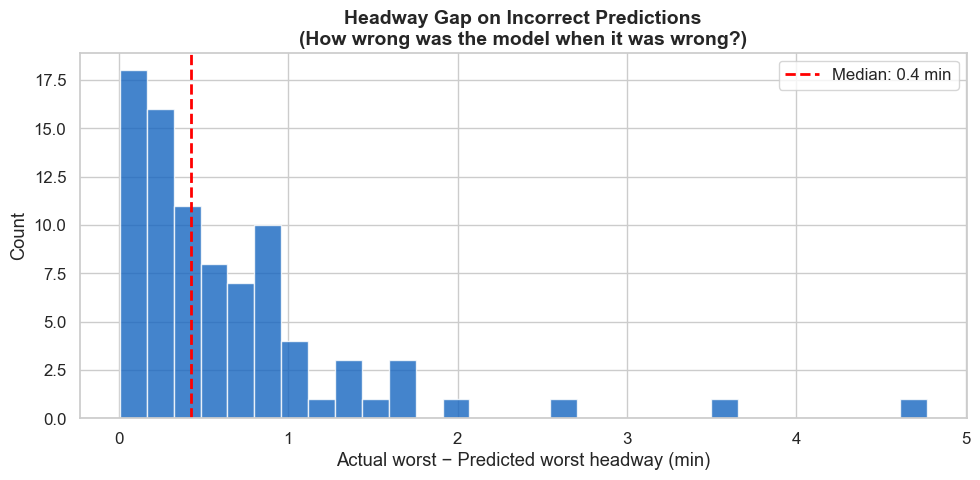

In [103]:
# Show how close the headways are on days the model gets "wrong"
wrong_days = comparison[comparison["predicted_worst"] != comparison["actual_worst"]]

# For each wrong prediction, what was the headway difference?
wrong_margins = []
for _, row in wrong_days.iterrows():
    day_data = pred_df[pred_df["service_date"] == row["service_date"]]
    actual_hw    = day_data.loc[day_data["branch_route_id"] == row["actual_worst"],
                                "avg_headway"].values
    predicted_hw = day_data.loc[day_data["branch_route_id"] == row["predicted_worst"],
                                "avg_headway"].values
    if len(actual_hw) > 0 and len(predicted_hw) > 0:
        wrong_margins.append({
            "service_date":    row["service_date"],
            "actual_worst":    row["actual_worst"],
            "predicted_worst": row["predicted_worst"],
            "margin_seconds":  actual_hw[0] - predicted_hw[0],
            "margin_minutes":  (actual_hw[0] - predicted_hw[0]) / 60
        })

margins_df = pd.DataFrame(wrong_margins)
print(f"Avg headway difference on wrong predictions: "
      f"{margins_df['margin_minutes'].mean():.1f} min")
print(f"Median headway difference on wrong predictions: "
      f"{margins_df['margin_minutes'].median():.1f} min")
print(f"\nDistribution of margins:")
print(margins_df["margin_minutes"].describe().round(2))

# Plot margin distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(margins_df["margin_minutes"], bins=30,
        color="#1565C0", alpha=0.8, edgecolor="white")
ax.axvline(margins_df["margin_minutes"].median(), color="red",
           linestyle="--", linewidth=2,
           label=f"Median: {margins_df['margin_minutes'].median():.1f} min")
ax.set_title("Headway Gap on Incorrect Predictions\n"
             "(How wrong was the model when it was wrong?)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Actual worst − Predicted worst headway (min)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("17_wrong_prediction_margins.png", dpi=150, bbox_inches="tight")
plt.show()

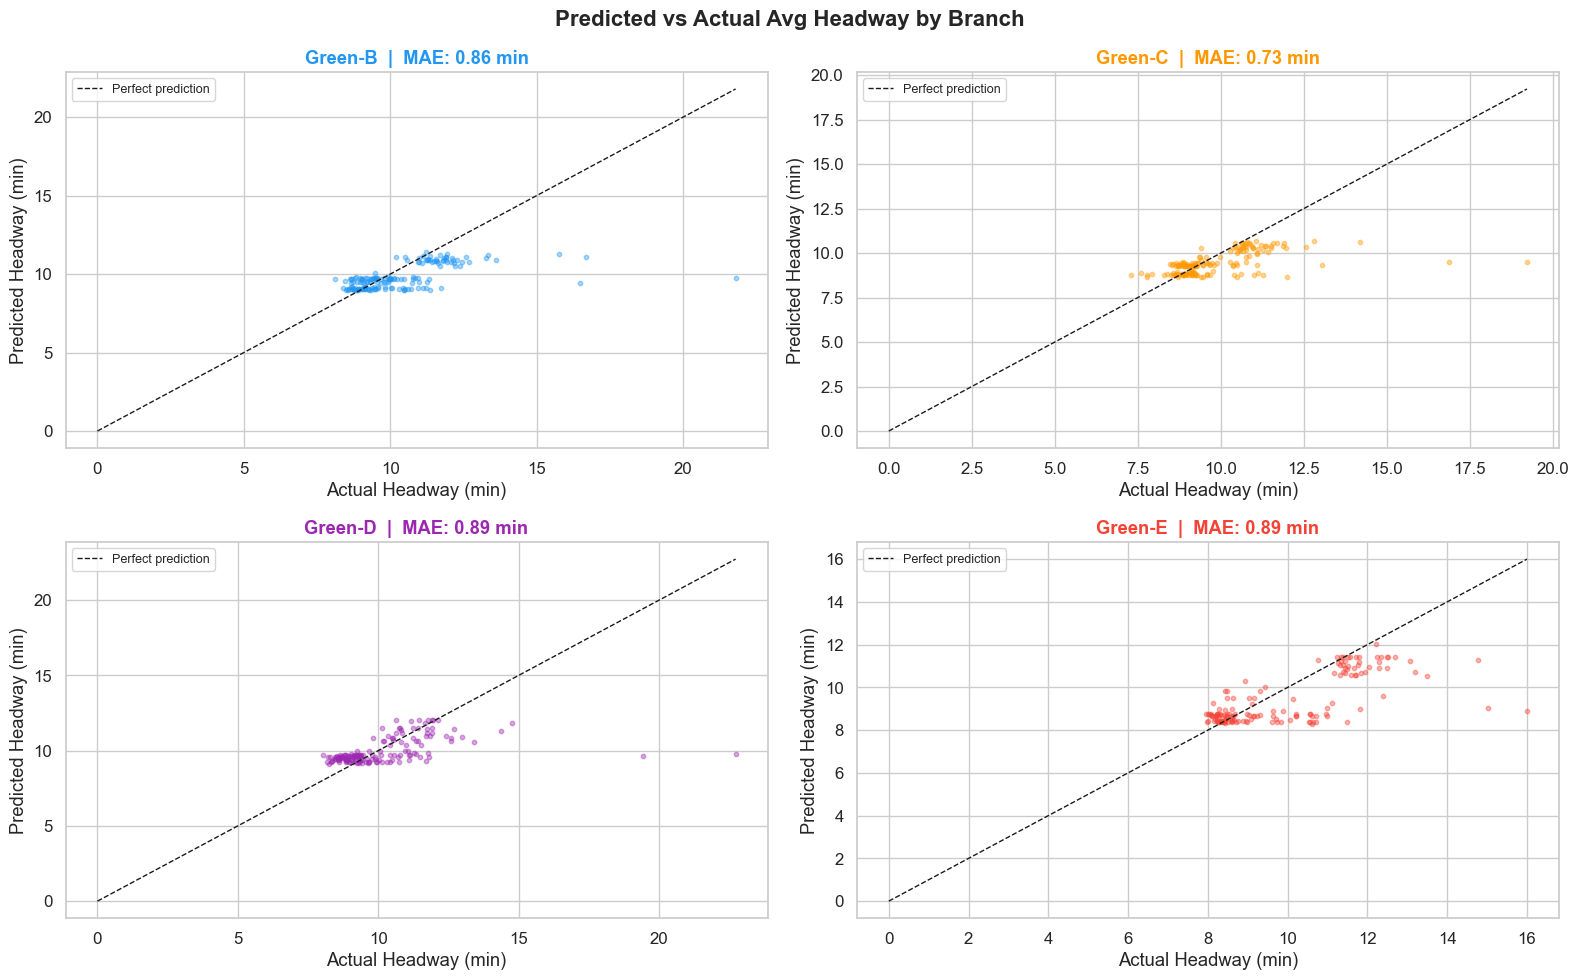

In [ ]:
# ── Visualization 1: Predicted vs actual headway per branch ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Predicted vs Actual Avg Headway by Branch",
             fontsize=16, fontweight="bold")

for ax, branch in zip(axes.flat, BRANCHES):
    res = branch_results[branch]
    ax.scatter(res["y_test"] / 60, res["test_preds"] / 60,
               alpha=0.4, s=10, color=BRANCH_COLORS[branch])

    # Perfect prediction line
    lim = max(res["y_test"].max(), res["test_preds"].max()) / 60
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="Perfect prediction")

    ax.set_title(f"{branch}  |  MAE: {res['mae']/60:.2f} min",
                 fontweight="bold", color=BRANCH_COLORS[branch])
    ax.set_xlabel("Actual Headway (min)")
    ax.set_ylabel("Predicted Headway (min)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("13_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

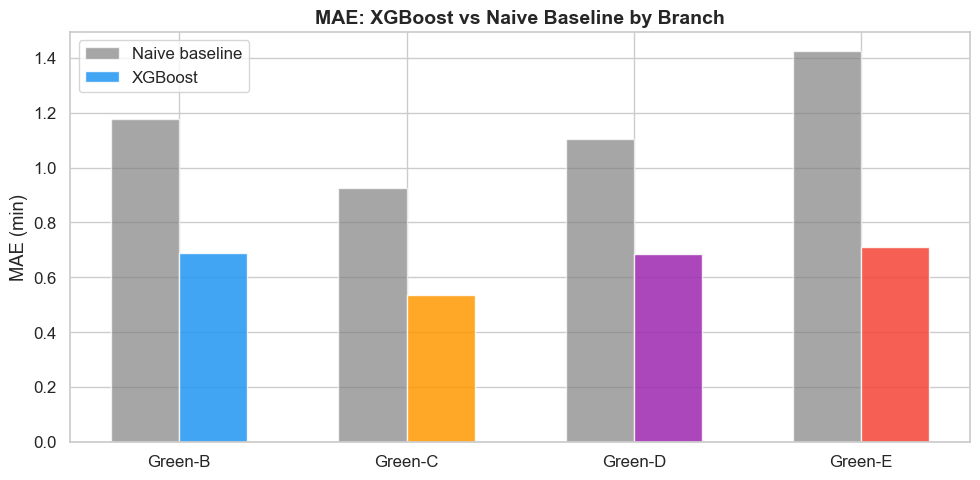

In [106]:
# ── Visualization 2: MAE comparison across branches ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

maes       = [branch_results[b]["mae"] / 60       for b in BRANCHES]
naive_maes = [branch_results[b]["naive_mae"] / 60 for b in BRANCHES]

x = np.arange(len(BRANCHES))
w = 0.3

ax.bar(x - w/2, naive_maes, width=w, label="Naive baseline",
       color="gray", alpha=0.7)
ax.bar(x + w/2, maes,       width=w, label="XGBoost",
       color=[BRANCH_COLORS[b] for b in BRANCHES], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(BRANCHES)
ax.set_title("MAE: XGBoost vs Naive Baseline by Branch",
             fontsize=14, fontweight="bold")
ax.set_ylabel("MAE (min)")
ax.legend()
plt.tight_layout()
plt.savefig("14_mae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()